In [1]:
import os
from os.path import expanduser
home = expanduser("~/")

import sys
sys.path.insert(0, home+'/gigalens'+'/src')
print('MASTER BRANCH GIGALENS')

srcdir = os.path.join(home, "gigalens/src/")

MASTER BRANCH GIGALENS


In [2]:
from gigalens.jax.inference import ModellingSequence
from gigalens.jax.model import ForwardProbModel, BackwardProbModel
from gigalens.model import PhysicalModel
from gigalens.jax.simulator import LensSimulator
from gigalens.simulator import SimulatorConfig
from gigalens.jax.profiles.light import sersic
from gigalens.jax.profiles.mass import epl, shear

import tensorflow_probability.substrates.jax as tfp
import jax
from jax import random
import numpy as np
import optax
from jax import numpy as jnp
from matplotlib import pyplot as plt
import optax
from helpers import *
import yaml
tfd = tfp.distributions

/global/homes/l/linusu/.conda/envs/jax-gigalens-multinode/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/global/homes/l/linusu//gigalens/src/gigalens/jax/inference.py:28: UserWarning: jax.distributed.initialize() was not called. For multinode, please call it before running any JAX functions.
  warnings.warn('jax.distributed.initialize() was not called. For multinode, please call it before running any JAX functions.')


In [3]:
prior = make_default_prior()
kernel = np.load(os.path.join(srcdir, 'gigalens/assets/psf.npy')).astype(np.float32)
sim_config = SimulatorConfig(delta_pix=0.065, num_pix=80, supersample=2, kernel=kernel)
phys_model = PhysicalModel([epl.EPL(50), shear.Shear()], [sersic.SersicEllipse(use_lstsq=False)], [sersic.SersicEllipse(use_lstsq=False)])
lens_sim = LensSimulator(phys_model, sim_config, bs=1)

systems_dir = os.path.join(home, "GIGALens-Code/SystemSaves")
f = np.load(os.path.join(systems_dir, "100SystemsStandard80px.npz"))
observed_imgs = jnp.array([f[key] for key in f.files])

observed_img = observed_imgs[60]

filename = os.path.join(systems_dir, '100SystemsStandardParams.yaml')
with open(filename, 'r') as file:
    true_params_list = params_lists_to_jax(yaml.safe_load(file))

true_params = jax.tree_util.tree_map(lambda a : a[60], true_params_list)

background_rms = 0.2
exp_time = 100
prob_model = ForwardProbModel(prior, observed_img, background_rms=background_rms, exp_time=exp_time)
model_seq = ModellingSequence(phys_model, prob_model, sim_config)

In [10]:
results_dir = os.path.join(home, f"GIGALens-Code/pipeline_results/100standard80px/60")
results_0 = {}
results_0["MAP"] = MAPResults.load(results_dir, model_seq)
results_0["SVI"] = SVIResults.load(results_dir, model_seq)
results_0["HMC"] = HMCResults.load(results_dir, model_seq)

results_dir = os.path.join(home, f"GIGALens-Code/pipeline_results/100standard80px_refined/60")
results_1 = {}
results_1["MAP"] = MAPResults.load(results_dir, model_seq)
results_1["SVI"] = SVIResults.load(results_dir, model_seq)
results_1["HMC"] = HMCResults.load(results_dir, model_seq)

results_dir = os.path.join(home, f"GIGALens-Code/sys60_converged")
results_2 = {}
results_2["MAP"] = MAPResults.load(results_dir, model_seq)
results_2["SVI"] = SVIResults.load(results_dir, model_seq)
results_2["HMC"] = HMCResults.load(results_dir, model_seq)

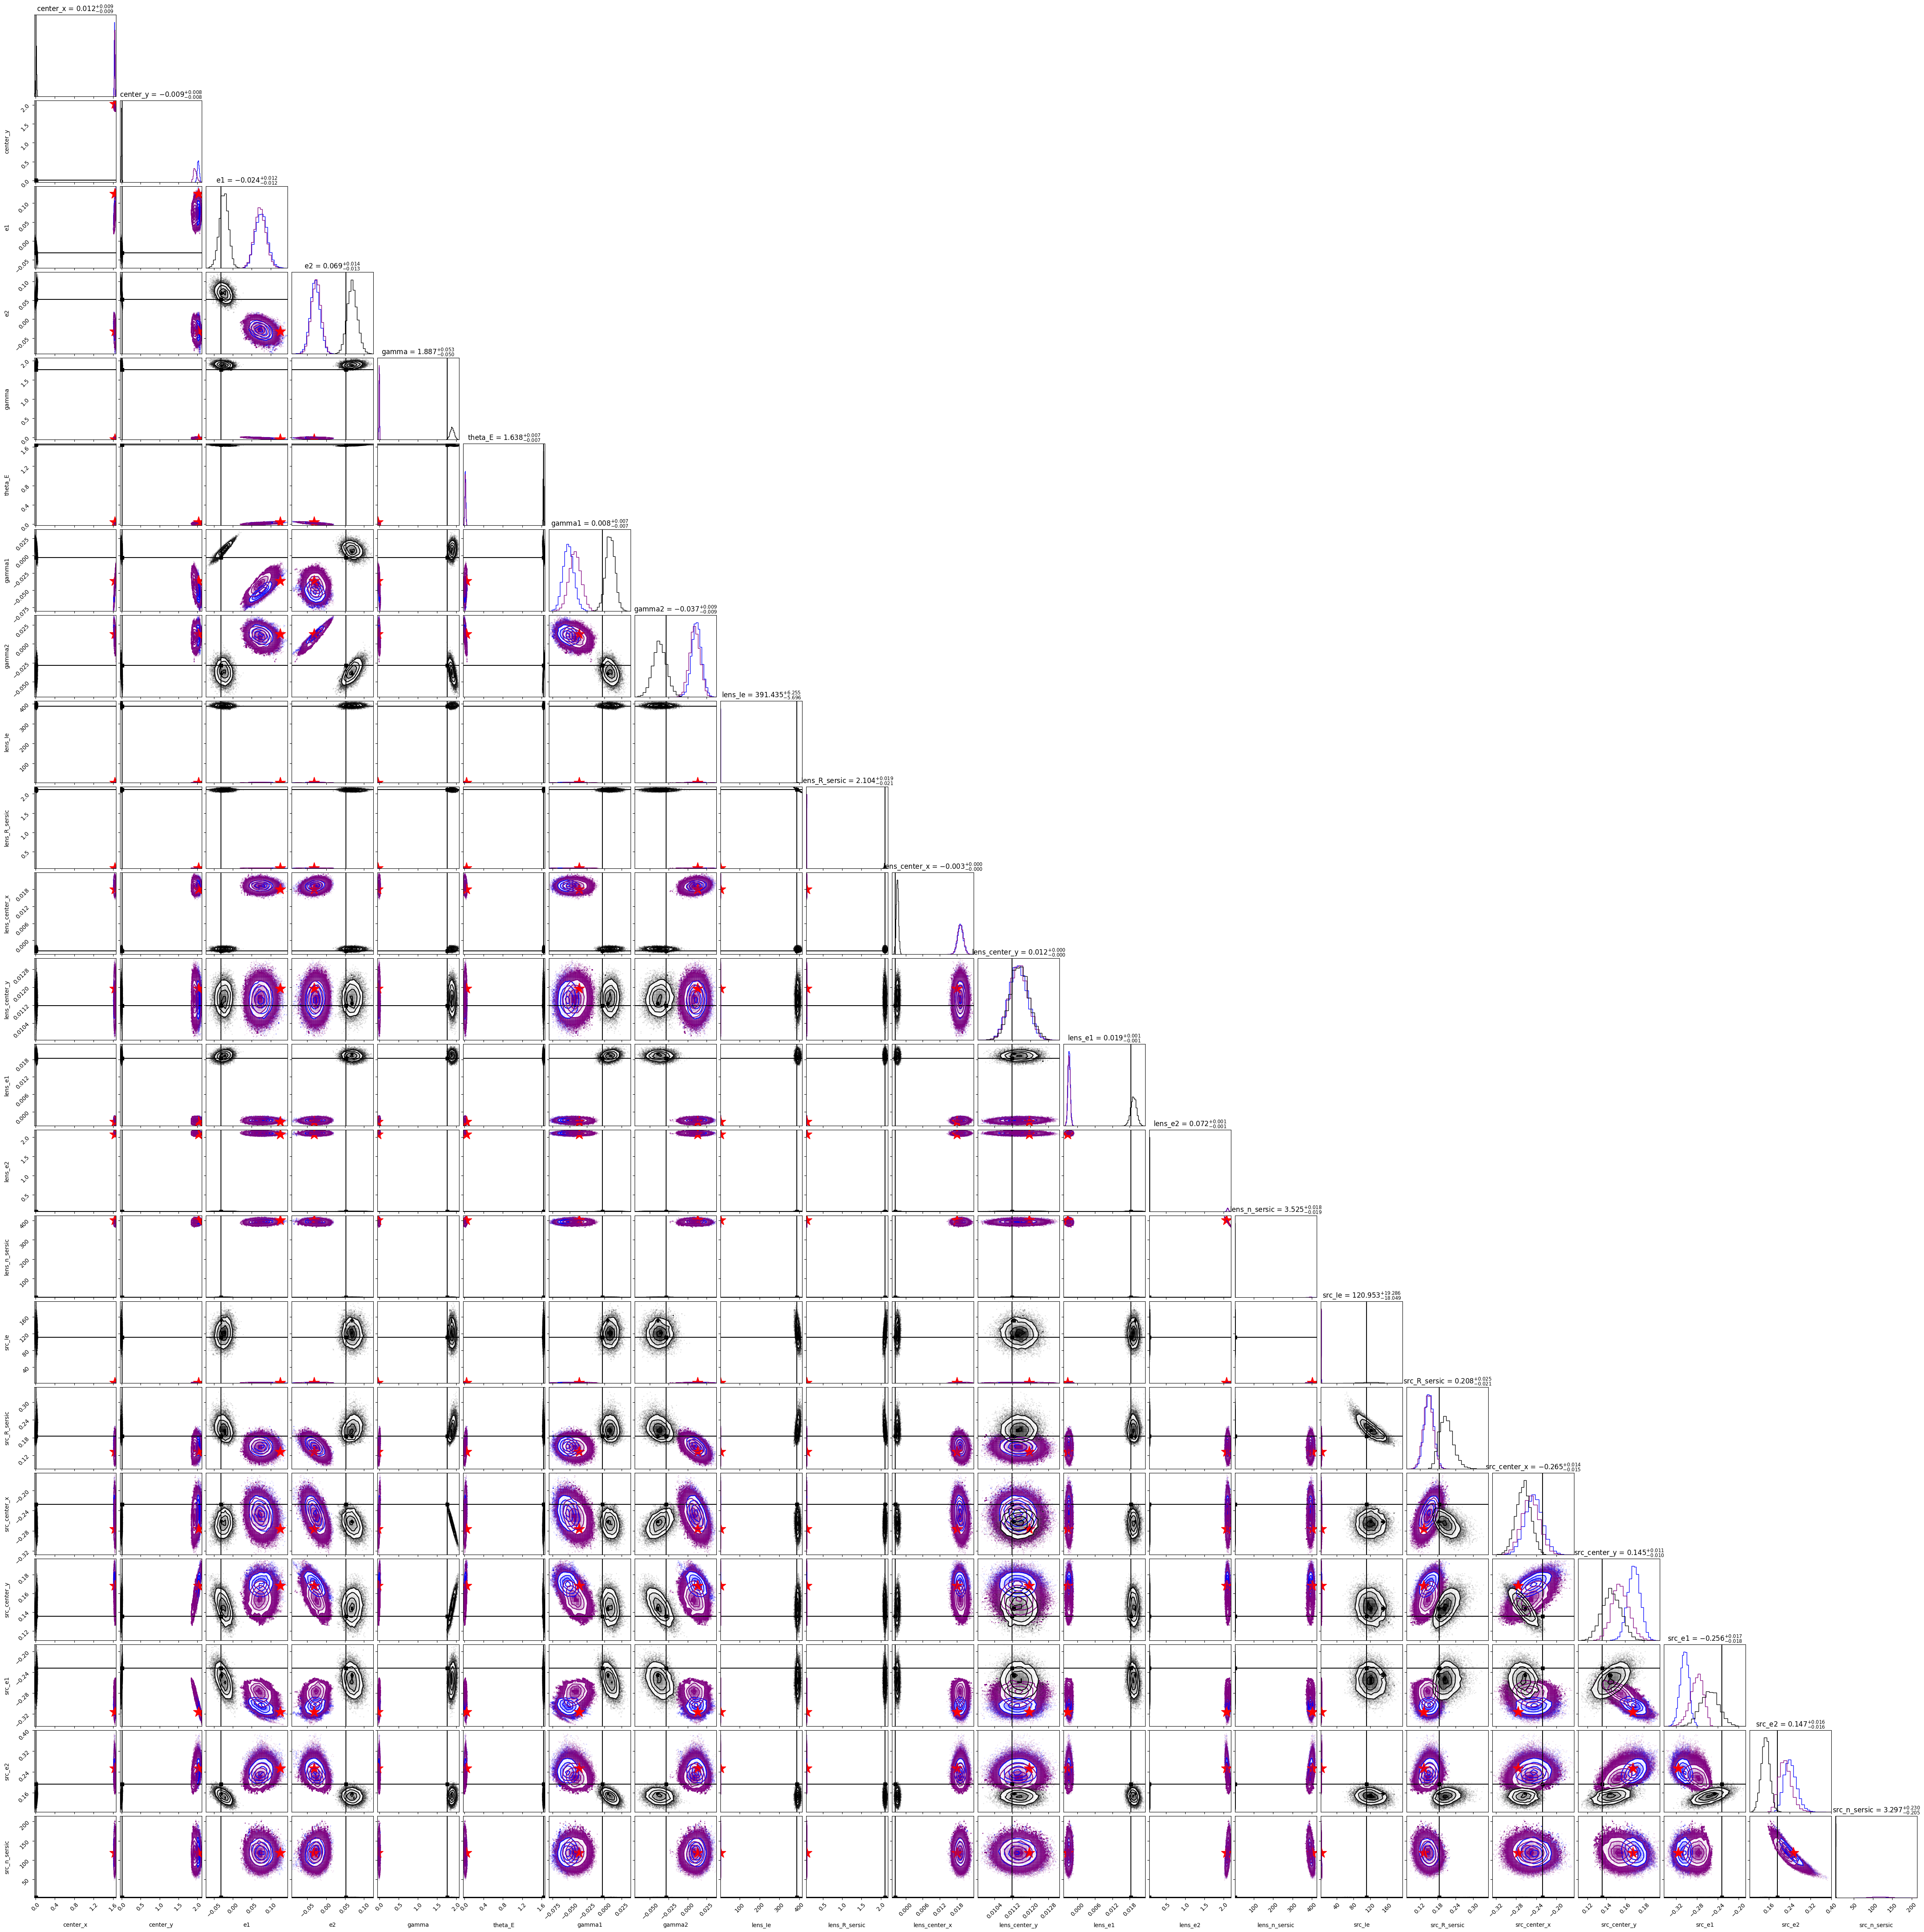

In [ ]:
labels = cornerplot_labels(true_params)

fig = cornerplot_posterior(labels, results_0["HMC"].HMC_samples, truth=true_params, overplots=results_0["MAP"].MAP_best, color='blue', truth_color='black', overplot_color='red')
cornerplot_posterior(labels, results_1["HMC"].HMC_samples, color='purple',fig=fig)

n_samp = results_2['HMC'].HMC_samples[0][0]['e1'].shape[0]
rand_idx = np.random.choice(np.arange(n_samp), size=(20000,), replace=True)
cornerplot_posterior(labels, jax.tree.map(lambda x: x[rand_idx], results_2['HMC'].HMC_samples), fig=fig)
plt.show()

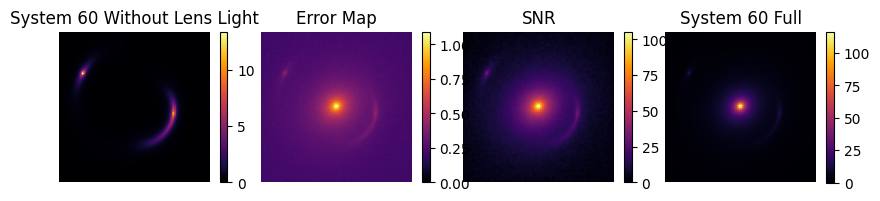

In [6]:
fig, axs = plt.subplots(1, 4)
fig.set_size_inches(10, 4)
err_map = jnp.sqrt(
    background_rms ** 2 + jnp.clip(observed_img, 0, np.inf) / exp_time
)
plot_image(fig, axs[0], lens_sim.simulate([true_params[0], [], true_params[2]]))
axs[0].set_title("System 60 Without Lens Light")
plot_image(fig, axs[1], err_map)
axs[1].set_title("Error Map")
plot_image(fig, axs[2], observed_img/err_map)
axs[2].set_title("SNR")
plot_image(fig, axs[3], lens_sim.simulate(true_params))
axs[3].set_title("System 60 Full")
plt.show()

In [7]:
true_params

[[{'center_x': Array(0.00622974, dtype=float32),
   'center_y': Array(0.01001453, dtype=float32),
   'e1': Array(-0.03198112, dtype=float32),
   'e2': Array(0.05299168, dtype=float32),
   'gamma': Array(1.7618887, dtype=float32),
   'theta_E': Array(1.6466328, dtype=float32)},
  {'gamma1': Array(-0.00272187, dtype=float32),
   'gamma2': Array(-0.02857415, dtype=float32)}],
 [{'Ie': Array(388.74942, dtype=float32),
   'R_sersic': Array(2.1126778, dtype=float32),
   'center_x': Array(-0.00367206, dtype=float32),
   'center_y': Array(0.01117988, dtype=float32),
   'e1': Array(0.01833759, dtype=float32),
   'e2': Array(0.0706927, dtype=float32),
   'n_sersic': Array(3.5304623, dtype=float32)}],
 [{'Ie': Array(111.72496, dtype=float32),
   'R_sersic': Array(0.18498771, dtype=float32),
   'center_x': Array(-0.22731827, dtype=float32),
   'center_y': Array(0.13541971, dtype=float32),
   'e1': Array(-0.23172717, dtype=float32),
   'e2': Array(0.19236542, dtype=float32),
   'n_sersic': Array(3.

FileNotFoundError: [Errno 2] No such file or directory: 'mask.npz'

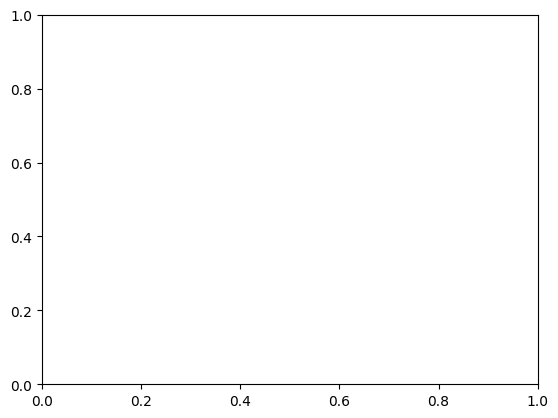

In [8]:
fig, ax = plt.gcf(), plt.gca()
mask = np.load("mask.npz")['mask']
masked = mask * observed_img/err_map
plot_image(fig, ax, masked)
plt.show()
flat_masked = masked.flatten()
np.mean(flat_masked[flat_masked!=0])

In [ ]:
import matplotlib.image

matplotlib.image.imsave('name.png', lens_sim.simulate([true_params[0], [], true_params[2]]))

In [ ]:
map_optimizer = optax.adabelief(1e-2, b1=0.95, b2=0.99) #nesterov=True may not be implemented in current optax
map_estimate, map_loss_hist = model_seq.MAP(map_optimizer, seed=0, n_samples=5000, num_steps=1000)

  0%|          | 0/1000 [00:01<?, ?it/s]


KeyboardInterrupt: 

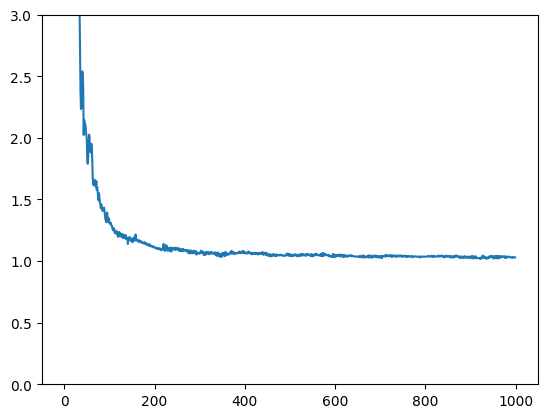

In [ ]:
plt.plot(map_loss_hist)
plt.ylim(bottom=0, top=3)
plt.show()

In [ ]:
lps = prob_model.log_prob(LensSimulator(phys_model, sim_config, bs=5000), map_estimate)[0]
best = map_estimate[jnp.nanargmax(lps)][jnp.newaxis,:]

In [ ]:
svi_optimizer = optax.adabelief(1e-4, b1=0.95, b2=0.99)
qz, loss_hist = model_seq.SVI(best, svi_optimizer, n_vi=1000, num_steps=1500)

ELBO: -314.404: 100%|██████████| 1500/1500 [01:58<00:00, 12.61it/s]


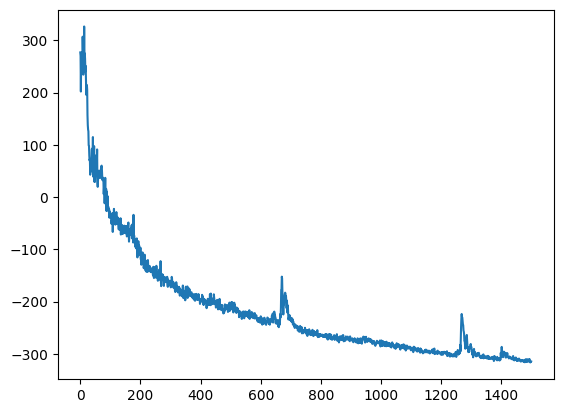

In [ ]:
plt.plot(loss_hist)

In [ ]:
samples = model_seq.HMC(qz, num_burnin_steps=250, num_results=750)

Sampling took 56.5s


In [ ]:
smp = jnp.transpose(samples.all_states, (1, 2, 0, 3)).reshape((-1, 22))
hmc_median = jnp.median(smp, axis=0)[jnp.newaxis,:]

In [ ]:
rhat= tfp.mcmc.potential_scale_reduction(jnp.transpose(samples.all_states, (1,2,0,3)), independent_chain_ndims=2)